In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import torch
from tqdm import tqdm

In [ ]:
data=np.load('/home/kjaworski/Pulpit/Temporal_thermal_imaging/all_data_extrapolated/param_fbh_gaussian_size5mm_depth80pct_thickness6mm.npz',allow_pickle=True)
bscan=data['data'][:,200,:]
mask=data['mask'][200,:]
bscan=torch.from_numpy(bscan).float()
mask=torch.from_numpy(mask).float()

In [ ]:
from helper_functions.helper_functions import NoiseAddition,RandomHorizontalFlipBscan,TwoDefect,HorizontalShift
noise=NoiseAddition(sigma_min=0.15, sigma_max=1.5)
ranflip=RandomHorizontalFlipBscan(p=0.5)
twodef=TwoDefect(p=1)
horizontalshift=HorizontalShift(p=1,min_shift=250,max_shift=450)


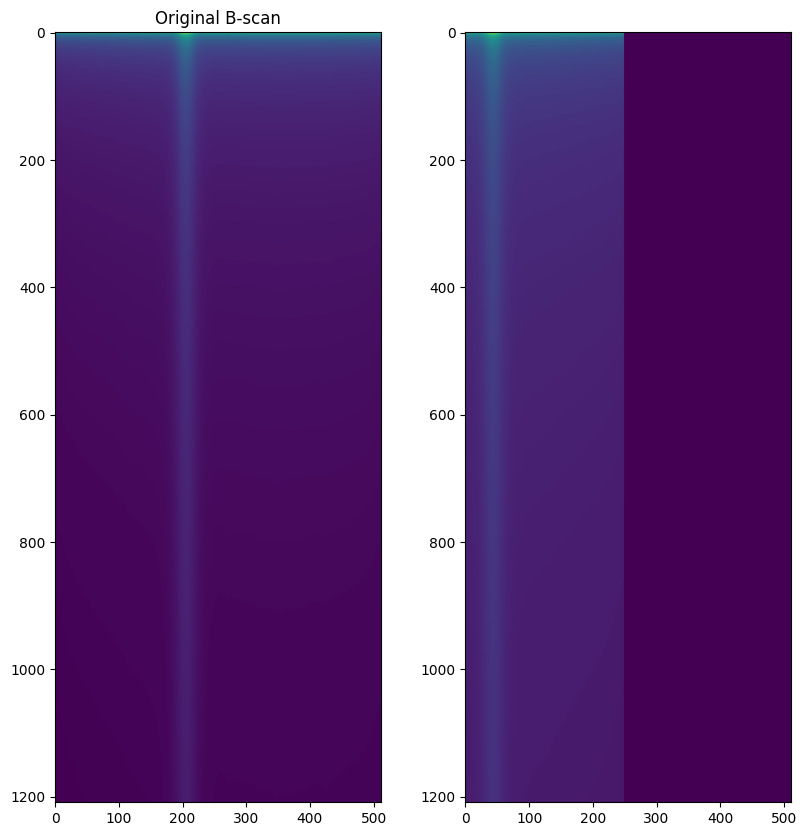

In [ ]:
# bscan_noisy,depth=noise(bscan, data['mask'])
# bscan_flipped,mask_flip=ranflip(bscan, mask)
# bscan_new,mask_new=twodef(bscan,mask)
bscan_new,mask_new=horizontalshift(bscan,mask)
plt.figure(figsize=(15,10))
plt.subplot(1,3,1)
plt.imshow(bscan)
plt.title("Original B-scan")
plt.subplot(1,3,2)
plt.imshow(bscan_new)
plt.title("Modified B-scan")
plt.subplot(1,3,3)
plt.plot(mask_new)
plt.title('Modified ground truth')

In [16]:
idx

tensor([343])

In [8]:
bscan.size()

torch.Size([1209, 512])

In [9]:
bscan_new.size()

torch.Size([1209, 512])